In [102]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

In [103]:
df = pd.read_csv("../data/processed/healthcare_cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5000, 18)


In [104]:
display(df.head())

,PatientID,Name,Age,Gender,DiagnosisID,AdmissionDate,DischargeDate,OutcomeID,TreatmentCost,LengthOfStay,DiagnosisName,OutcomeName,Blood Pressure,Blood Sugar,Cholesterol,Creatinine,Hemoglobin,Vitamin D
0,1,Aarav Sharma,89,F,10,2026-07-06,2026-07-16,3,7495,10,Liver Disease,Deceased,130.04,135.70,204.00,1.03,13.72,33.53
1,2,Vivaan Banerjee,41,M,6,2025-11-22,2025-11-24,1,3348,2,COPD,Recovered,115.35,93.75,160.33,0.85,15.22,42.17
2,3,Aditya Malhotra,35,F,9,2025-01-22,2025-01-25,1,3504,3,Kidney Disease,Recovered,118.02,95.16,136.25,1.37,14.05,41.54
3,4,Arjun Choudhary,73,M,9,2024-07-01,2024-07-10,3,7097,9,Kidney Disease,Deceased,145.10,126.79,180.61,1.72,12.48,27.82
4,5,Rohan Kumar,45,M,10,2024-10-10,2024-10-13,1,3852,3,Liver Disease,Recovered,118.26,106.44,182.04,0.86,14.64,37.39


In [105]:
print("Outcome distribution:")
print(df["OutcomeName"].value_counts())

print("\nOutcome percentages:")
print(
    df["OutcomeName"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Outcome distribution:
OutcomeName
Recovered      3250
Complicated    1250
Deceased        500
Name: count, dtype: int64

Outcome percentages:
OutcomeName
Recovered      65.0
Complicated    25.0
Deceased       10.0
Name: proportion, dtype: float64


In [106]:
missing_values = df.isnull().sum()

display(
    missing_values[missing_values > 0]
)

Series([], dtype: int64)

In [107]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [108]:
print("Columns in dataset:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in dataset:
1. PatientID
2. Name
3. Age
4. Gender
5. DiagnosisID
6. AdmissionDate
7. DischargeDate
8. OutcomeID
9. TreatmentCost
10. LengthOfStay
11. DiagnosisName
12. OutcomeName
13. Blood Pressure
14. Blood Sugar
15. Cholesterol
16. Creatinine
17. Hemoglobin
18. Vitamin D


In [109]:
columns_to_remove = [
    "PatientID",
    "Name",
    "AdmissionDate",
    "DischargeDate",
    "OutcomeName"
]

df_ml = df.drop(columns=columns_to_remove)

print("Original shape:", df.shape)
print("ML dataset shape:", df_ml.shape)

display(df_ml.head())

Original shape: (5000, 18)
ML dataset shape: (5000, 13)


,Age,Gender,DiagnosisID,OutcomeID,TreatmentCost,LengthOfStay,DiagnosisName,Blood Pressure,Blood Sugar,Cholesterol,Creatinine,Hemoglobin,Vitamin D
0,89,F,10,3,7495,10,Liver Disease,130.04,135.70,204.00,1.03,13.72,33.53
1,41,M,6,1,3348,2,COPD,115.35,93.75,160.33,0.85,15.22,42.17
2,35,F,9,1,3504,3,Kidney Disease,118.02,95.16,136.25,1.37,14.05,41.54
3,73,M,9,3,7097,9,Kidney Disease,145.10,126.79,180.61,1.72,12.48,27.82
4,45,M,10,1,3852,3,Liver Disease,118.26,106.44,182.04,0.86,14.64,37.39


In [110]:
X = df_ml.drop(columns=["OutcomeID"])
y = df_ml["OutcomeID"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 12)
Target shape: (5000,)


In [111]:
print("Target distribution:")
print(y.value_counts().sort_index())

Target distribution:
OutcomeID
1    3250
2    1250
3     500
Name: count, dtype: int64


In [112]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Gender', 'DiagnosisName']

Numerical columns:
['Age', 'DiagnosisID', 'TreatmentCost', 'LengthOfStay', 'Blood Pressure', 'Blood Sugar', 'Cholesterol', 'Creatinine', 'Hemoglobin', 'Vitamin D']


C:\Users\Dipa\AppData\Local\Temp\ipykernel_11100\705693328.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [113]:
# Remove columns that should not be used for outcome prediction
columns_to_remove_ml = [
    "TreatmentCost",
    "LengthOfStay",
    "DiagnosisName"
]

X = X.drop(columns=columns_to_remove_ml)

print("Remaining features:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)

Remaining features:
['Age', 'Gender', 'DiagnosisID', 'Blood Pressure', 'Blood Sugar', 'Cholesterol', 'Creatinine', 'Hemoglobin', 'Vitamin D']

Feature shape: (5000, 9)


In [114]:
categorical_columns = X.select_dtypes(
    include=["str", "object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Gender']

Numerical columns:
['Age', 'DiagnosisID', 'Blood Pressure', 'Blood Sugar', 'Cholesterol', 'Creatinine', 'Hemoglobin', 'Vitamin D']


In [115]:
print("Target variable: OutcomeID")

print("\nClass counts:")
print(y.value_counts().sort_index())

print("\nClass percentages:")
print(
    y.value_counts(normalize=True)
     .sort_index()
     .mul(100)
     .round(2)
)

Target variable: OutcomeID

Class counts:
OutcomeID
1    3250
2    1250
3     500
Name: count, dtype: int64

Class percentages:
OutcomeID
1    65.0
2    25.0
3    10.0
Name: proportion, dtype: float64


In [116]:
# Treat diagnosis as a categorical feature
X["DiagnosisID"] = X["DiagnosisID"].astype(str)

categorical_columns = [
    "Gender",
    "DiagnosisID"
]

numerical_columns = [
    "Age",
    "Blood Pressure",
    "Blood Sugar",
    "Cholesterol",
    "Creatinine",
    "Hemoglobin",
    "Vitamin D"
]

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Gender', 'DiagnosisID']

Numerical columns:
['Age', 'Blood Pressure', 'Blood Sugar', 'Cholesterol', 'Creatinine', 'Hemoglobin', 'Vitamin D']


In [117]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4000, 9)
X_test : (1000, 9)
y_train: (4000,)
y_test : (1000,)


In [118]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [119]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [120]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (4000, 9)
Processed X_train shape: (4000, 19)

Original X_test shape: (1000, 9)
Processed X_test shape: (1000, 19)


In [121]:
preprocessor.fit_transform(X_train)

array([[-0.87289186,  0.2767407 ,  1.01964916, ...,  0.        ,
         0.        ,  0.        ],
       [-0.71590868, -0.08734177, -1.79540821, ...,  0.        ,
         0.        ,  0.        ],
       [-1.08220276, -1.20114669, -0.55507918, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.29728689, -0.52687554, -0.23720911, ...,  0.        ,
         1.        ,  0.        ],
       [-1.13453048, -0.28495232, -1.20862005, ...,  0.        ,
         0.        ,  0.        ],
       [-1.29151366, -1.59636779, -0.15837733, ...,  0.        ,
         0.        ,  0.        ]], shape=(4000, 19))

In [122]:
preprocessor.transform(X_test)

array([[ 0.33064581, -0.58436224, -0.23657337, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.48762898, -0.94604943,  2.27078576, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.01667946,  1.72588473, -0.69430628, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.34384138, -1.6059489 , -1.83164539, ...,  0.        ,
         0.        ,  0.        ],
       [-0.03564826, -1.63229698, -0.18444268, ...,  0.        ,
         0.        ,  0.        ],
       [-1.29151366, -0.30411455, -1.79286525, ...,  0.        ,
         0.        ,  0.        ]], shape=(1000, 19))

In [123]:
print("Processed training data type:", type(X_train_processed))
print("Processed test data type:", type(X_test_processed))

Processed training data type: <class 'numpy.ndarray'>
Processed test data type: <class 'numpy.ndarray'>


In [124]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed features:")
for feature in feature_names:
    print(feature)

Number of processed features: 19

Processed features:
numerical__Age
numerical__Blood Pressure
numerical__Blood Sugar
numerical__Cholesterol
numerical__Creatinine
numerical__Hemoglobin
numerical__Vitamin D
categorical__Gender_F
categorical__Gender_M
categorical__DiagnosisID_1
categorical__DiagnosisID_10
categorical__DiagnosisID_2
categorical__DiagnosisID_3
categorical__DiagnosisID_4
categorical__DiagnosisID_5
categorical__DiagnosisID_6
categorical__DiagnosisID_7
categorical__DiagnosisID_8
categorical__DiagnosisID_9


In [125]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

display(X_train_processed_df.head())

,numerical__Age,numerical__Blood Pressure,numerical__Blood Sugar,numerical__Cholesterol,numerical__Creatinine,numerical__Hemoglobin,numerical__Vitamin D,categorical__Gender_F,categorical__Gender_M,categorical__DiagnosisID_1,categorical__DiagnosisID_10,categorical__DiagnosisID_2,categorical__DiagnosisID_3,categorical__DiagnosisID_4,categorical__DiagnosisID_5,categorical__DiagnosisID_6,categorical__DiagnosisID_7,categorical__DiagnosisID_8,categorical__DiagnosisID_9
243,-0.872892,0.276741,1.019649,0.983015,0.867202,0.073717,-1.566746,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
653,-0.715909,-0.087342,-1.795408,0.321225,-0.960828,0.926899,-0.580223,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
271,-1.082203,-1.201147,-0.555079,-0.248137,-1.080048,0.417537,-0.124492,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3285,-0.715909,-0.452622,0.358479,0.167793,-0.841609,0.392069,0.001505,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3232,-0.349615,-0.029855,-0.212415,-0.126747,0.151885,-1.670847,0.886159,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [126]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [127]:
y_pred = rf_model.predict(X_test_processed)

print("Predictions generated successfully.")
print(y_pred[:20])

Predictions generated successfully.
[1 1 1 3 1 1 1 2 1 1 1 1 2 2 2 3 1 1 1 1]


In [128]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Recovered", "Complicated", "Deceased"]
    )
)

Accuracy: 0.8540

Classification Report:
              precision    recall  f1-score   support

   Recovered       0.92      0.93      0.92       650
 Complicated       0.71      0.70      0.71       250
    Deceased       0.80      0.76      0.78       100

    accuracy                           0.85      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.85      0.85      0.85      1000



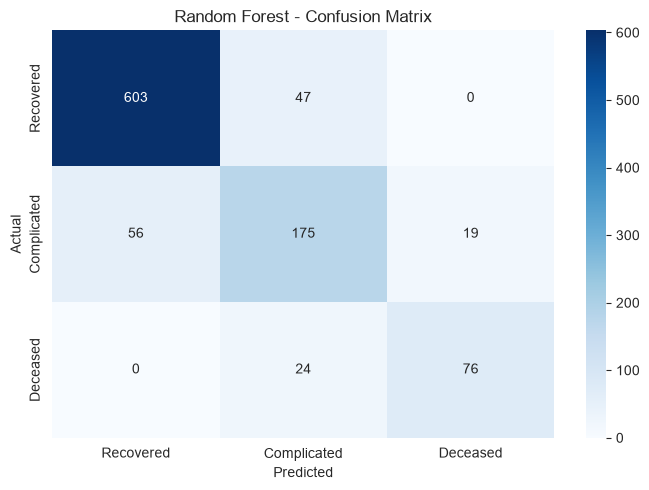

In [129]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Recovered", "Complicated", "Deceased"],
    yticklabels=["Recovered", "Complicated", "Deceased"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [130]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_balanced.fit(
    X_train_processed,
    y_train
)

print("Balanced Random Forest training completed.")

Balanced Random Forest training completed.


In [131]:
y_pred_balanced = rf_balanced.predict(
    X_test_processed
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [132]:
accuracy_balanced = accuracy_score(
    y_test,
    y_pred_balanced
)

print(f"Accuracy: {accuracy_balanced:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=[
            "Recovered",
            "Complicated",
            "Deceased"
        ]
    )
)

Accuracy: 0.8460

Classification Report:
              precision    recall  f1-score   support

   Recovered       0.94      0.89      0.92       650
 Complicated       0.67      0.76      0.71       250
    Deceased       0.75      0.78      0.76       100

    accuracy                           0.85      1000
   macro avg       0.79      0.81      0.80      1000
weighted avg       0.86      0.85      0.85      1000



In [133]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.0


In [134]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.0


In [136]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train - 1
)

print("XGBoost training completed.")

XGBoost training completed.


In [137]:
y_pred_xgb = xgb_model.predict(
    X_test_processed
)

# Convert XGBoost classes back to original OutcomeID
y_pred_xgb = y_pred_xgb + 1

print("Predictions generated successfully.")
print(y_pred_xgb[:20])

Predictions generated successfully.
[1 1 1 3 1 2 1 3 1 1 1 1 2 2 2 3 1 1 1 1]


In [138]:
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")

print("\nXGBoost Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            "Recovered",
            "Complicated",
            "Deceased"
        ]
    )
)

XGBoost Accuracy: 0.8440

XGBoost Classification Report:
              precision    recall  f1-score   support

   Recovered       0.92      0.92      0.92       650
 Complicated       0.68      0.70      0.69       250
    Deceased       0.76      0.74      0.75       100

    accuracy                           0.84      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.85      0.84      0.84      1000



In [139]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train - 1
)

print("Sample weights calculated.")
print("Minimum weight:", sample_weights.min())
print("Maximum weight:", sample_weights.max())

Sample weights calculated.
Minimum weight: 0.5128205128205128
Maximum weight: 3.3333333333333335


In [140]:
xgb_weighted = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_weighted.fit(
    X_train_processed,
    y_train - 1,
    sample_weight=sample_weights
)

print("Weighted XGBoost training completed.")

Weighted XGBoost training completed.


In [141]:
y_pred_xgb_weighted = xgb_weighted.predict(
    X_test_processed
)

y_pred_xgb_weighted = y_pred_xgb_weighted + 1

print("Predictions generated successfully.")

Predictions generated successfully.


In [142]:
accuracy_xgb_weighted = accuracy_score(
    y_test,
    y_pred_xgb_weighted
)

print(f"Weighted XGBoost Accuracy: {accuracy_xgb_weighted:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_xgb_weighted,
        target_names=[
            "Recovered",
            "Complicated",
            "Deceased"
        ]
    )
)

Weighted XGBoost Accuracy: 0.8410

Classification Report:
              precision    recall  f1-score   support

   Recovered       0.94      0.89      0.91       650
 Complicated       0.67      0.72      0.69       250
    Deceased       0.72      0.81      0.76       100

    accuracy                           0.84      1000
   macro avg       0.77      0.81      0.79      1000
weighted avg       0.85      0.84      0.84      1000



In [143]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [144]:
from imblearn.over_sampling import SMOTE
print("Before SMOTE:")
print(y_train.value_counts().sort_index())

Before SMOTE:
OutcomeID
1    2600
2    1000
3     400
Name: count, dtype: int64


In [145]:
smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts().sort_index())

After SMOTE:
OutcomeID
1    2600
2    2600
3    2600
Name: count, dtype: int64


In [146]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

print("SMOTE Random Forest training completed.")

SMOTE Random Forest training completed.


In [147]:
y_pred_rf_smote = rf_smote.predict(
    X_test_processed
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [148]:
accuracy_rf_smote = accuracy_score(
    y_test,
    y_pred_rf_smote
)

print(f"SMOTE Random Forest Accuracy: {accuracy_rf_smote:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf_smote,
        target_names=[
            "Recovered",
            "Complicated",
            "Deceased"
        ]
    )
)

SMOTE Random Forest Accuracy: 0.8420

Classification Report:
              precision    recall  f1-score   support

   Recovered       0.94      0.89      0.92       650
 Complicated       0.68      0.70      0.69       250
    Deceased       0.70      0.85      0.77       100

    accuracy                           0.84      1000
   macro avg       0.77      0.82      0.79      1000
weighted avg       0.85      0.84      0.84      1000



In [149]:
xgb_smote = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_smote.fit(
    X_train_smote,
    y_train_smote - 1
)

print("SMOTE XGBoost training completed.")

SMOTE XGBoost training completed.


In [150]:
y_pred_xgb_smote = xgb_smote.predict(
    X_test_processed
)

y_pred_xgb_smote = y_pred_xgb_smote + 1

print("Predictions generated successfully.")

Predictions generated successfully.


In [151]:
accuracy_xgb_smote = accuracy_score(
    y_test,
    y_pred_xgb_smote
)

print(f"SMOTE XGBoost Accuracy: {accuracy_xgb_smote:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_xgb_smote,
        target_names=[
            "Recovered",
            "Complicated",
            "Deceased"
        ]
    )
)

SMOTE XGBoost Accuracy: 0.8350

Classification Report:
              precision    recall  f1-score   support

   Recovered       0.94      0.89      0.91       650
 Complicated       0.66      0.70      0.68       250
    Deceased       0.67      0.84      0.75       100

    accuracy                           0.83      1000
   macro avg       0.76      0.81      0.78      1000
weighted avg       0.85      0.83      0.84      1000

